Project Title

Customer Segmentation for Retail Store using K-Means Clustering

Objective

Group customers based on purchasing behavior so that the retail store can create targeted marketing strategies.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


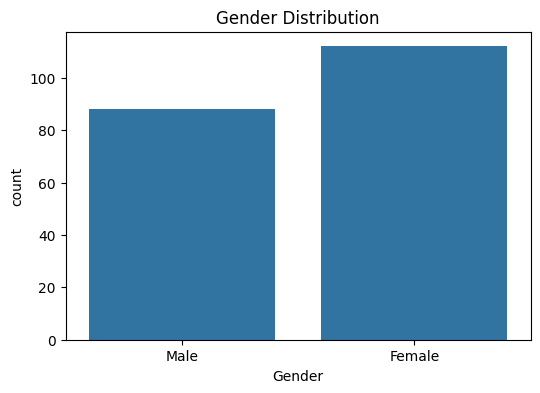

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.show()

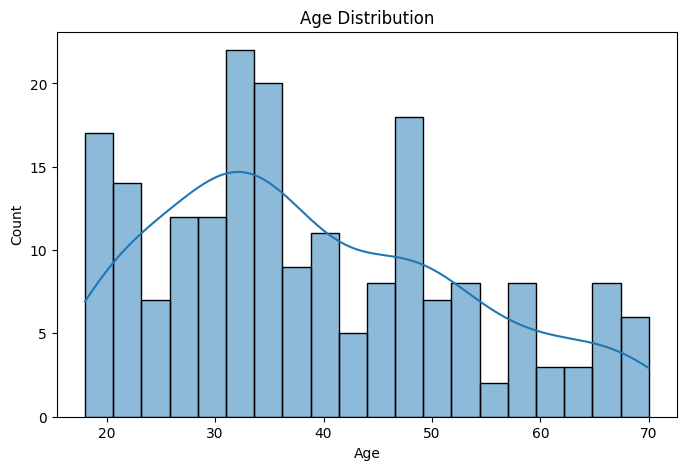

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()


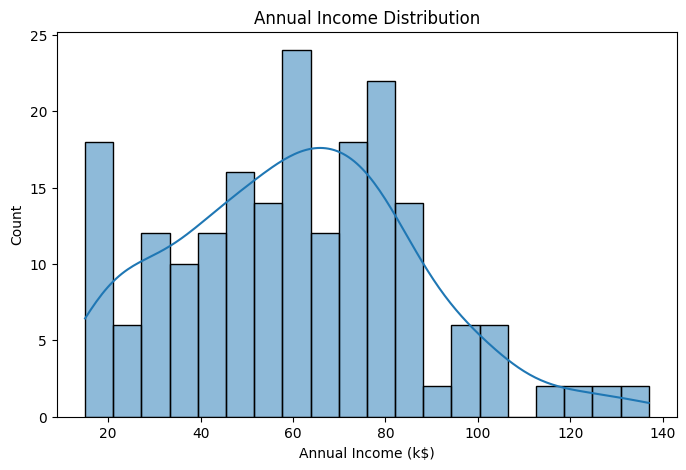

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.show()

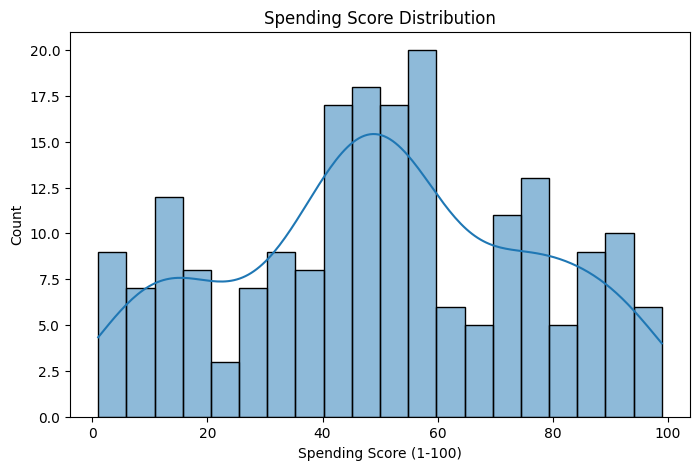

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.show()

In [11]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

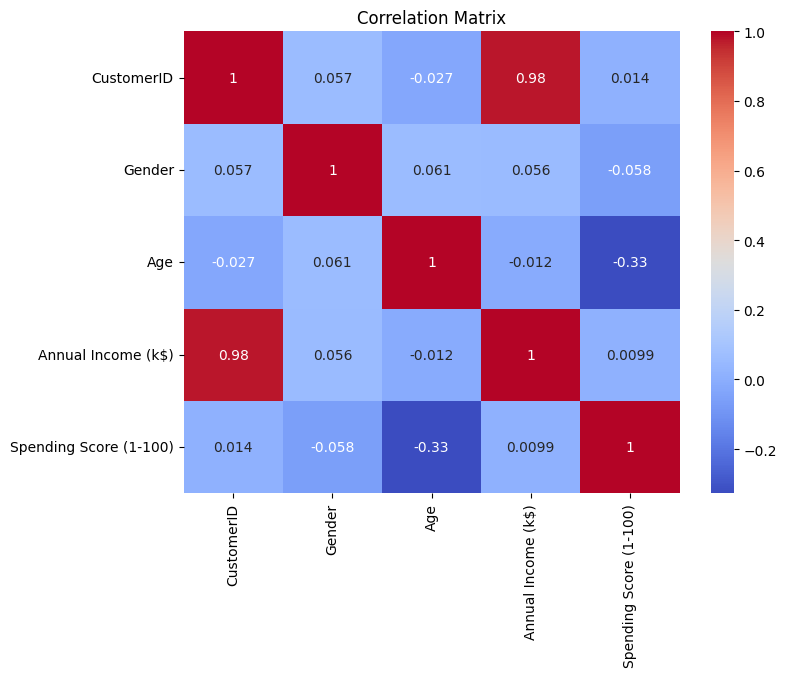

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [13]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

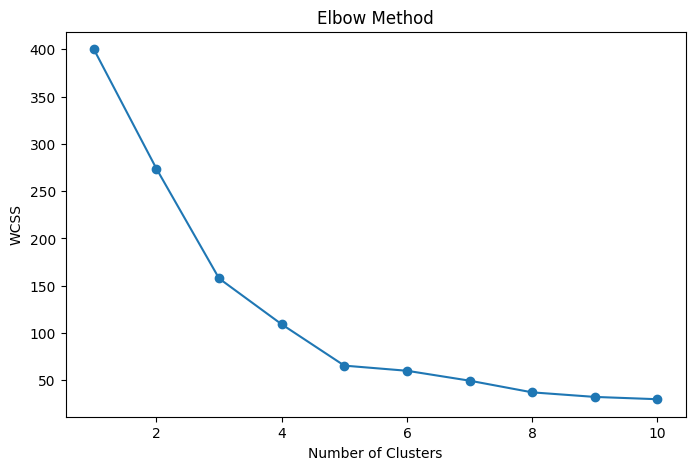

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [17]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k} : {score:.3f}")

K=2 : 0.397
K=3 : 0.467
K=4 : 0.494
K=5 : 0.555
K=6 : 0.514
K=7 : 0.502
K=8 : 0.455
K=9 : 0.457
K=10 : 0.445


In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [19]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


In [20]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


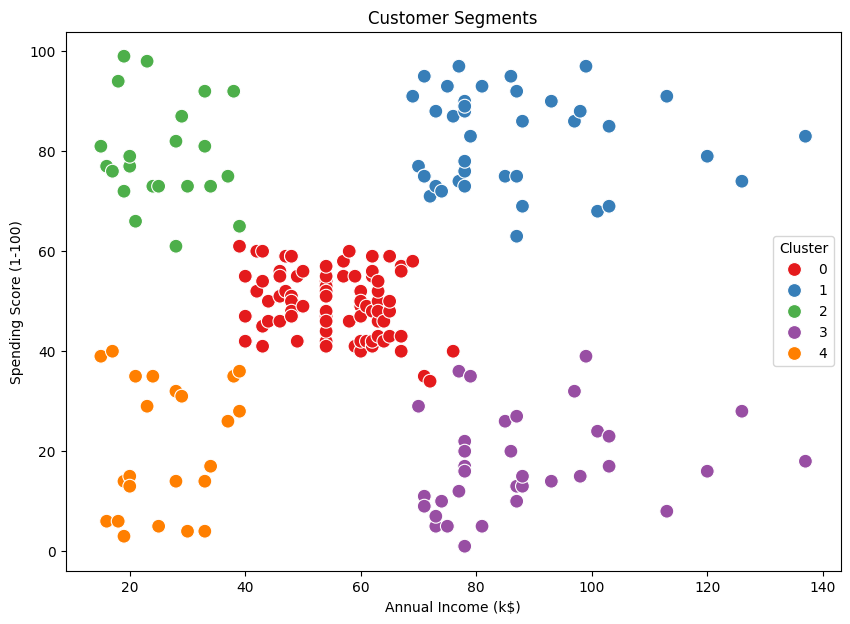

In [21]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segments")

plt.show()

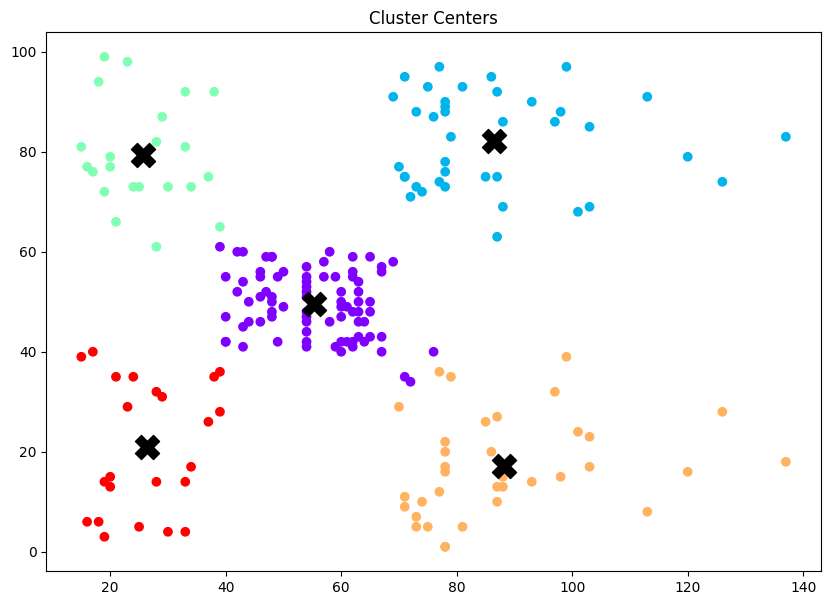

In [23]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(10,7))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='rainbow'
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    c='black',
    marker='X'
)

plt.title("Cluster Centers")

plt.show()

In [22]:
cluster_summary = df.groupby('Cluster').agg({
    'Age':'mean',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean'
})

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [24]:
segment_names = {
    0:'Premium Customers',
    1:'High Income Low Spending',
    2:'Budget Customers',
    3:'Regular Customers',
    4:'Young High Spenders'
}

df['Segment'] = df['Cluster'].map(segment_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,1,19,15,39,4,Young High Spenders
1,2,1,21,15,81,2,Budget Customers
2,3,0,20,16,6,4,Young High Spenders
3,4,0,23,16,77,2,Budget Customers
4,5,0,31,17,40,4,Young High Spenders


In [25]:
df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [26]:
income = float(input("Enter Annual Income: "))
score = float(input("Enter Spending Score: "))

new_customer = scaler.transform(
    [[income, score]]
)

prediction = kmeans.predict(
    new_customer
)

print("Cluster:", prediction[0])

Enter Annual Income: 100000
Enter Spending Score: 65000
Cluster: 1


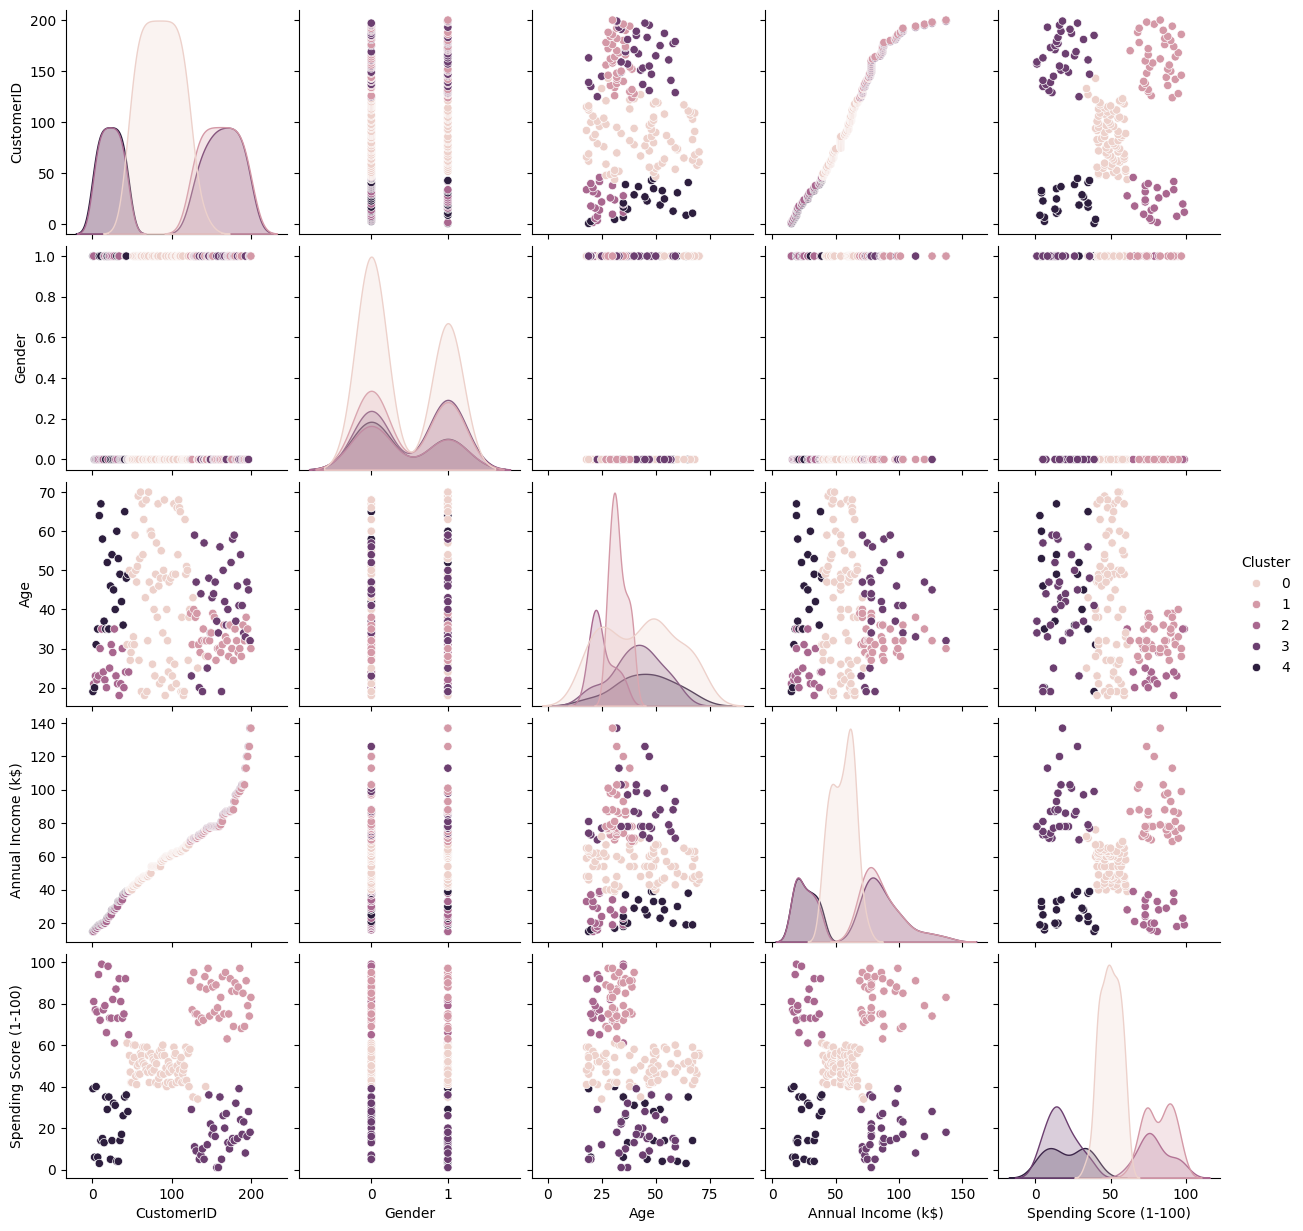

In [28]:
sns.pairplot(
    df,
    hue='Cluster'
)

plt.show()

In [31]:
from mpl_toolkits.mplot3d import Axes3D

In [32]:
recommendations = {
    "Premium Customers":
    "Offer loyalty rewards",

    "Budget Customers":
    "Provide discount coupons",

    "High Income Low Spending":
    "Run personalized campaigns"
}